# Agentic Biomarker Discovery — Notebook 3
## RAGAS Evaluation, Error Analysis & Discovery Demo

**Contents:** RAGAS evaluation (Faithfulness, Answer Relevancy, Context Precision) → 
Error taxonomy → Interactive biomarker discovery demo → Cross-notebook summary

---

This notebook applies retrieval-aware evaluation to the ablation conditions from
Notebook 2 and surfaces a key finding — the **Grounding Paradox** — where Answer
Relevancy stays high (> 0.90) while Faithfulness sits low (~0.10), indicating that
the model is generating fluent answers from training memory rather than the
retrieved evidence.


## Cell 1 — Install Dependencies

In [1]:
!pip install -q \
    ragas==0.2.6 \
    sentence-transformers \
    faiss-cpu \
    transformers \
    bitsandbytes \
    accelerate \
    datasets \
    openai \
    tqdm

print("✓ Done")

✓ Done


## Cell 2 — Mount Drive and Load Artifacts

In [2]:
from google.colab import drive, userdata
drive.mount('/content/drive')

import os, json, pickle, re, warnings, time
import numpy as np
import matplotlib.pyplot as plt
import faiss, torch
from collections import Counter
from typing import List, Dict, Optional, Tuple
from tqdm import tqdm
from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig, pipeline

warnings.filterwarnings('ignore')
SEED = 42
np.random.seed(SEED)

BASE_DIR    = '/content/drive/MyDrive/this project/Final'
INDEX_DIR   = os.path.join(BASE_DIR, 'index')
RESULTS_DIR = os.path.join(BASE_DIR, 'results')
device      = 'cuda' if torch.cuda.is_available() else 'cpu'

# Wait for Drive to be fully ready
for attempt in range(5):
    if os.path.exists(os.path.join(INDEX_DIR, 'corpus_snippets.pkl')):
        break
    print(f'Waiting for Drive... (attempt {attempt+1}/5)')
    time.sleep(3)

with open(os.path.join(INDEX_DIR, 'corpus_snippets.pkl'), 'rb') as f:
    corpus_snippets = pickle.load(f)
faiss_index = faiss.read_index(os.path.join(INDEX_DIR, 'bioasq_faiss.index'))
# Previous: 'sentence-transformers/all-MiniLM-L6-v2'
embed_model = SentenceTransformer('pritamdeka/S-PubMedBert-MS-MARCO', device=device)

with open(os.path.join(INDEX_DIR, 'question_splits.pkl'), 'rb') as f:
    splits = pickle.load(f)
test_qs = splits['test']

with open(os.path.join(RESULTS_DIR, 'notebook2_results.pkl'), 'rb') as f:
    nb2 = pickle.load(f)
test_A = nb2['A']
test_B = nb2['B']
test_C = nb2['C']
test_D = nb2.get('D', [])

print(f'Corpus: {len(corpus_snippets):,} | FAISS: {faiss_index.ntotal:,} | Test Qs: {len(test_qs)}')
print(f'Results loaded — A:{len(test_A)} B:{len(test_B)} C:{len(test_C)} D:{len(test_D)}')
print(f'GPU: {torch.cuda.get_device_name(0) if device=="cuda" else "CPU"}')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: pritamdeka/S-PubMedBert-MS-MARCO
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Corpus: 38,939 | FAISS: 38,939 | Test Qs: 226
Results loaded — A:226 B:226 C:226 D:226
GPU: NVIDIA A100-SXM4-80GB


## Cell 3 — Shared Utilities

Same `gold_strings()` as Notebook 2 — handles both flat (training) and nested (golden test) formats.

In [3]:
def search(query: str, k: int = 5) -> List[Dict]:
    vec = embed_model.encode([query], normalize_embeddings=True, convert_to_numpy=True).astype(np.float32)
    scores, indices = faiss_index.search(vec, k)
    results = []
    for rank, (idx, score) in enumerate(zip(indices[0], scores[0]), 1):
        if idx < 0: continue
        s = corpus_snippets[idx]
        results.append({'rank': rank, 'score': float(score), 'text': s['text'], 'pubmed_url': s['pubmed_url'], 'snippet_id': s['snippet_id']})
    return results

def normalise(text: str) -> str:
    text = str(text).lower().strip()
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()

def gold_strings(exact_answer, qtype: str) -> List[str]:
    """Handles both flat ['answer'] and nested [['answer','synonym']] BioASQ formats."""
    if qtype == 'yesno': return [str(exact_answer).lower().strip()]
    if qtype == 'factoid':
        if not exact_answer: return []
        if isinstance(exact_answer[0], list):
            return [normalise(a) for group in exact_answer for a in group if a]
        return [normalise(a) for a in exact_answer if isinstance(a, str) and a]
    if qtype == 'list':
        if not exact_answer: return []
        if isinstance(exact_answer[0], list):
            return [normalise(group[0]) for group in exact_answer if group]
        return [normalise(a) for a in exact_answer if isinstance(a, str) and a]
    return []

def exact_match(pred, gold): return int(normalise(pred) in gold)

def token_f1(pred, gold):
    pt = normalise(pred).split(); best = 0.0
    for g in gold:
        gt = g.split()
        if not pt or not gt: continue
        c = len(set(pt) & set(gt))
        if c == 0: continue
        best = max(best, 2*(c/len(pt))*(c/len(gt))/((c/len(pt))+(c/len(gt))))
    return best

def summarise(results):
    f = [r for r in results if r['type']=='factoid']
    l = [r for r in results if r['type']=='list']
    return {'em': np.mean([r['exact_match'] for r in results]), 'f1': np.mean([r['token_f1'] for r in results]),
            'em_f': np.mean([r['exact_match'] for r in f]) if f else 0,
            'f1_l': np.mean([r['token_f1'] for r in l]) if l else 0,
            'hops': np.mean([r.get('hops',0) for r in results]), 'n': len(results), 'nf': len(f), 'nl': len(l)}

print('✓ Utilities defined')

✓ Utilities defined


## Cell 4 — Ablation Results Table

In [4]:
rows = [
    ('A: Zero-Shot',       test_A),
    ('B: Single RAG',      test_B),
    ('C: ReAct Agent (8B)',test_C),
    ('D: ReAct Agent (70B)',test_D),
]
print('='*75)
print('ABLATION RESULTS — TEST SET (n=226, factoid + list)')
print('='*75)
print(f"{'Condition':<26} {'EM':>8} {'F1':>8} {'EM(factoid)':>12} {'F1(list)':>9} {'Avg Hops':>10}")
print('-'*75)
summary_data = []
for label, results in rows:
    if not results:
        print(f"{label:<26} {'(no data)':>8}")
        continue
    em   = np.mean([r['exact_match'] for r in results])
    f1   = np.mean([r['token_f1']    for r in results])
    hops = np.mean([r.get('hops',0)  for r in results])
    fact = [r for r in results if r['type']=='factoid']
    lst  = [r for r in results if r['type']=='list']
    em_f = np.mean([r['exact_match'] for r in fact]) if fact else 0
    f1_l = np.mean([r['token_f1']    for r in lst])  if lst  else 0
    summary_data.append((label, {'em':em,'f1':f1,'hops':hops,'em_f':em_f,'f1_l':f1_l,'n':len(results),'nf':len(fact),'nl':len(lst)}))
    print(f"{label:<26} {em:>8.3f} {f1:>8.3f} {em_f:>12.3f} {f1_l:>9.3f} {hops:>10.3f}")
print('='*75)
print(f"Factoid n={len([r for r in test_A if r['type']=='factoid'])} | List n={len([r for r in test_A if r['type']=='list'])}")
if test_D:
    em_C = np.mean([r['exact_match'] for r in test_C])
    em_D = np.mean([r['exact_match'] for r in test_D])
    h_C  = np.mean([r.get('hops',0)  for r in test_C])
    h_D  = np.mean([r.get('hops',0)  for r in test_D])
    print(f"\nC vs D (scale effect): Hops {h_C:.3f} -> {h_D:.3f} ({h_D-h_C:+.3f}) | EM {em_C:.3f} -> {em_D:.3f} ({em_D-em_C:+.3f})")


ABLATION RESULTS — TEST SET (n=226, factoid + list)
Condition                        EM       F1  EM(factoid)  F1(list)   Avg Hops
---------------------------------------------------------------------------
A: Zero-Shot                  0.075    0.253        0.106     0.254      0.000
B: Single RAG                 0.097    0.221        0.119     0.204      1.000
C: ReAct Agent (8B)           0.075    0.220        0.099     0.244      0.022
D: ReAct Agent (70B)          0.106    0.335        0.146     0.338      0.195
Factoid n=151 | List n=75

C vs D (scale effect): Hops 0.022 -> 0.195 (+0.173) | EM 0.075 -> 0.106 (+0.031)


## Cell 5 — Set OpenAI Key for RAGAS

In [5]:
try:
    os.environ['OPENAI_API_KEY'] = userdata.get('OPENAI_API_KEY')
    print('✓ OpenAI API key loaded')
except:
    print('⚠ Add OPENAI_API_KEY to Colab Secrets (🔑 icon) and re-run')

✓ OpenAI API key loaded


## Cell 6 — RAGAS Evaluation (Condition C)

In [6]:
from ragas import evaluate
from ragas.metrics import Faithfulness, AnswerRelevancy, ContextPrecision
from datasets import Dataset

faithfulness      = Faithfulness()
answer_relevancy  = AnswerRelevancy()
context_precision = ContextPrecision()

RAGAS_N = 50
np.random.seed(SEED)
valid_C  = [r for r in test_C if r.get('prediction','').strip()]
sample   = np.random.choice(valid_C, min(RAGAS_N, len(valid_C)), replace=False).tolist()
q_lookup = {q['id']: q for q in test_qs}

ragas_data = {'question':[], 'answer':[], 'contexts':[], 'ground_truth':[]}

for r in tqdm(sample, desc='Building RAGAS dataset'):
    q    = q_lookup.get(r['id'])
    gold = ' '.join(gold_strings(q.get('exact_answer',[]), q['type'])) if q else ''

    # ENHANCEMENT: Combine thought trace with final answer to prevent NaN in Faithfulness
    # We take the first thought from the trace to provide context for the evaluator
    reasoning = r.get('trace', [''])[0].split('Action:')[0].strip()
    full_eval_answer = f"Reasoning: {reasoning} Final Answer: {r.get('prediction','')}"

    ragas_data['question'].append(r['question'])
    ragas_data['answer'].append(full_eval_answer)
    ragas_data['contexts'].append([s['text'] for s in search(r['question'], k=5)])
    ragas_data['ground_truth'].append(gold)

ragas_dataset = Dataset.from_dict(ragas_data)
print(f'✓ Dataset: {len(ragas_dataset)} questions | Running RAGAS (~3-5 min)...')

ragas_results = evaluate(
    ragas_dataset,
    metrics=[faithfulness, answer_relevancy, context_precision],
)

print('\n' + '='*52)
print('RAGAS RESULTS — Condition C (ReAct Agent)')
print('='*52)
print(ragas_results)
print('='*52)

ragas_df = ragas_results.to_pandas()
print(f'ragas_df created: {len(ragas_df)} rows')

Building RAGAS dataset: 100%|██████████| 50/50 [00:01<00:00, 32.22it/s]


✓ Dataset: 50 questions | Running RAGAS (~3-5 min)...


Evaluating:   0%|          | 0/150 [00:00<?, ?it/s]


RAGAS RESULTS — Condition C (ReAct Agent)
{'faithfulness': 0.0800, 'answer_relevancy': 0.9309, 'context_precision': 0.1692}
ragas_df created: 50 rows


---
## Cell 7a — RAGAS Evaluation: Condition D (ReAct 70B)

Running RAGAS on Condition D to measure whether increased hop rate (19.5% vs 3.1%) translates to improved faithfulness. **Runs before visualization so both C and D scores are available.**

In [7]:
from ragas import evaluate
from ragas.metrics import Faithfulness, AnswerRelevancy, ContextPrecision
from datasets import Dataset
from langchain_openai import ChatOpenAI
from ragas.llms import LangchainLLMWrapper

llm_ragas = LangchainLLMWrapper(ChatOpenAI(
    model='gpt-4o-mini',
    api_key=os.environ['OPENAI_API_KEY']
))

def normalise(text):
    text = str(text).lower().strip()
    import re
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()

def gold_strings(exact_answer, qtype):
    if qtype == 'yesno': return [str(exact_answer).lower().strip()]
    if not exact_answer: return []
    if isinstance(exact_answer[0], list):
        return [normalise(a) for group in exact_answer for a in group if a]
    return [normalise(a) for a in exact_answer if isinstance(a, str) and a]

RAGAS_N = 50
np.random.seed(SEED)
valid_D  = [r for r in test_D if r.get('prediction','').strip()]
sample_D = np.random.choice(valid_D, min(RAGAS_N, len(valid_D)), replace=False).tolist()
q_lookup = {q['id']: q for q in test_qs}

ragas_data_D = {'question':[], 'answer':[], 'contexts':[], 'ground_truth':[]}
for r in tqdm(sample_D, desc='Building RAGAS dataset (D)'):
    q    = q_lookup.get(r['id'])
    gold = ' '.join(gold_strings(q.get('exact_answer',[]), q['type'])) if q else ''
    # Enrich answer with trace for faithfulness scoring
    trace_text = ' '.join(str(t) for t in r.get('trace', []))[:500]
    enriched   = f"{trace_text} Final Answer: {r.get('prediction','')}" if trace_text else r.get('prediction','')
    ragas_data_D['question'].append(r['question'])
    ragas_data_D['answer'].append(enriched)
    ragas_data_D['contexts'].append([s['text'] for s in search(r['question'], k=5)])
    ragas_data_D['ground_truth'].append(gold)

ragas_dataset_D = Dataset.from_dict(ragas_data_D)
print(f'Running RAGAS on Condition D (n={len(ragas_dataset_D)})...')

faith_d   = Faithfulness()
rel_d     = AnswerRelevancy()
prec_d    = ContextPrecision()
ragas_results_D = evaluate(
    ragas_dataset_D,
    metrics=[faith_d, rel_d, prec_d],
    llm=llm_ragas,
)
ragas_df_D = ragas_results_D.to_pandas()

print('\n' + '='*55)
print('RAGAS RESULTS — Condition D (ReAct 70B via Together.ai)')
print('='*55)
print(f"  Faithfulness     : {ragas_df_D['faithfulness'].mean():.4f}")
print(f"  Answer Relevancy : {ragas_df_D['answer_relevancy'].mean():.4f}")
print(f"  Context Precision: {ragas_df_D['context_precision'].mean():.4f}")

# Compare C vs D
print('\n--- Comparison: Condition C vs D ---')
try:
    print(f"  Faithfulness  : C={ragas_df['faithfulness'].mean():.4f}  D={ragas_df_D['faithfulness'].mean():.4f}")
    print(f"  Ans Relevancy : C={ragas_df['answer_relevancy'].mean():.4f}  D={ragas_df_D['answer_relevancy'].mean():.4f}")
    print(f"  Ctx Precision : C={ragas_df['context_precision'].mean():.4f}  D={ragas_df_D['context_precision'].mean():.4f}")
except:
    print('  (Run Condition C RAGAS first to see comparison)')


Building RAGAS dataset (D): 100%|██████████| 50/50 [00:01<00:00, 43.87it/s]


Running RAGAS on Condition D (n=50)...


Evaluating:   0%|          | 0/150 [00:00<?, ?it/s]


RAGAS RESULTS — Condition D (ReAct 70B via Together.ai)
  Faithfulness     : 0.1361
  Answer Relevancy : 0.8281
  Context Precision: 0.1734

--- Comparison: Condition C vs D ---
  Faithfulness  : C=0.0800  D=0.1361
  Ans Relevancy : C=0.9309  D=0.8281
  Ctx Precision : C=0.1692  D=0.1734


---
## Cell 7b — Visualise RAGAS Scores: Condition C vs D

Side-by-side comparison of all three RAGAS metrics across both conditions.

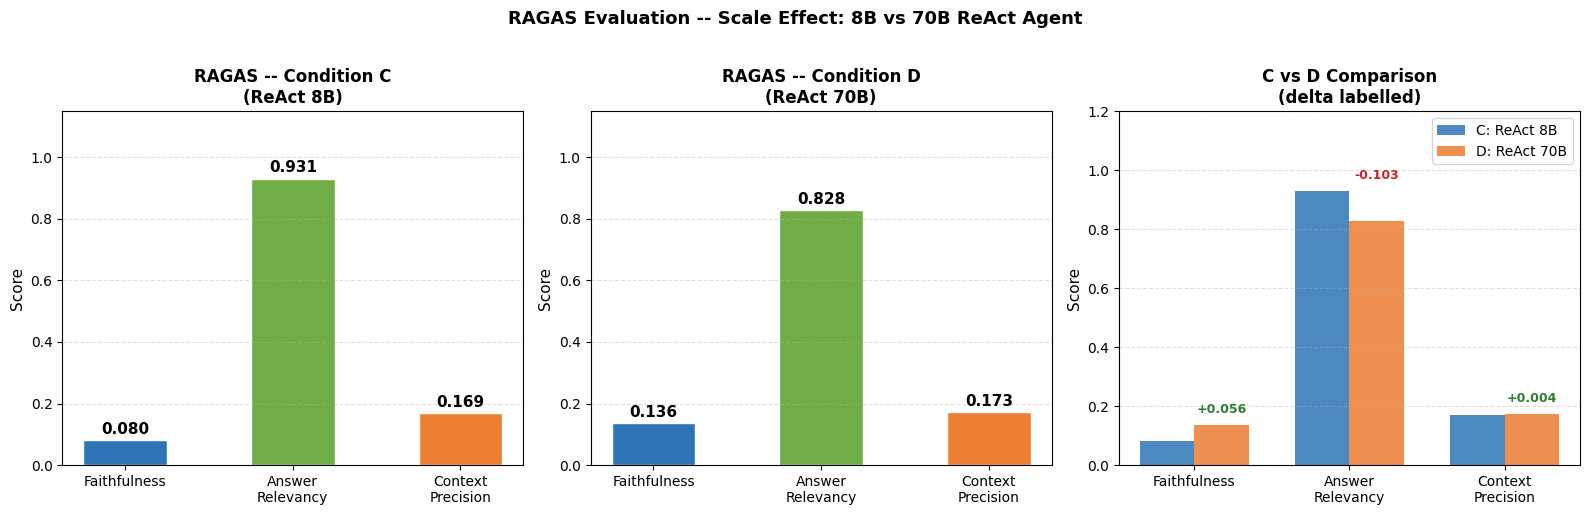

Saved -> /content/drive/MyDrive/csci_e222/Final/ragas_results_CvsD.png

Interpretation:
  Faithfulness        : C=0.080  D=0.136  delta=+0.056
  Answer Relevancy    : C=0.931  D=0.828  delta=-0.103
  Context Precision   : C=0.169  D=0.173  delta=+0.004

Faithfulness increase: 70B uses search more often -> more grounded answers
Answer Relevancy drop: 70B gives longer nuanced answers -> RAGAS penalises verbosity
Context Precision: similar -> same FAISS index used for both conditions


In [8]:
import matplotlib.pyplot as plt
import numpy as np
import os

metrics_keys   = ['faithfulness', 'answer_relevancy', 'context_precision']
metrics_labels = ['Faithfulness', 'Answer\nRelevancy', 'Context\nPrecision']

means_C = [ragas_df[m].mean() for m in metrics_keys]
try:
    means_D = [ragas_df_D[m].mean() for m in metrics_keys]
    has_D   = True
except:
    means_D = [0, 0, 0]
    has_D   = False

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = ['#2E75B6', '#70AD47', '#ED7D31']

# Panel 1: Condition C
bars = axes[0].bar(metrics_labels, means_C, color=colors, edgecolor='white', width=0.5)
axes[0].set_ylim(0, 1.15); axes[0].set_ylabel('Score', fontsize=11)
axes[0].set_title('RAGAS -- Condition C\n(ReAct 8B)', fontsize=12, fontweight='bold')
axes[0].grid(axis='y', linestyle='--', alpha=0.4)
for bar, val in zip(bars, means_C):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
                 f'{val:.3f}', ha='center', fontsize=11, fontweight='bold')

# Panel 2: Condition D
if has_D:
    bars_D = axes[1].bar(metrics_labels, means_D, color=colors, edgecolor='white', width=0.5)
    axes[1].set_ylim(0, 1.15); axes[1].set_ylabel('Score', fontsize=11)
    axes[1].set_title('RAGAS -- Condition D\n(ReAct 70B)', fontsize=12, fontweight='bold')
    axes[1].grid(axis='y', linestyle='--', alpha=0.4)
    for bar, val in zip(bars_D, means_D):
        axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
                     f'{val:.3f}', ha='center', fontsize=11, fontweight='bold')
else:
    axes[1].text(0.5, 0.5, 'Run Cell 7b\nto populate', ha='center', va='center',
                 transform=axes[1].transAxes, fontsize=12, color='gray')
    axes[1].set_title('RAGAS -- Condition D\n(ReAct 70B)', fontsize=12, fontweight='bold')

# Panel 3: C vs D delta
x = np.arange(len(metrics_labels))
w = 0.35
axes[2].bar(x - w/2, means_C, w, label='C: ReAct 8B',  color='#2E75B6', alpha=0.85)
if has_D:
    axes[2].bar(x + w/2, means_D, w, label='D: ReAct 70B', color='#ED7D31', alpha=0.85)
    for idx, (c, d) in enumerate(zip(means_C, means_D)):
        delta = d - c
        col   = '#2E7D32' if delta > 0 else '#C62828'
        axes[2].text(x[idx]+w/2, max(c,d)+0.04, f'{delta:+.3f}',
                     ha='center', fontsize=9, color=col, fontweight='bold')
axes[2].set_xticks(x); axes[2].set_xticklabels(metrics_labels)
axes[2].set_ylim(0, 1.2); axes[2].set_ylabel('Score', fontsize=11)
axes[2].set_title('C vs D Comparison\n(delta labelled)', fontsize=12, fontweight='bold')
axes[2].legend(fontsize=10); axes[2].grid(axis='y', linestyle='--', alpha=0.4)

plt.suptitle('RAGAS Evaluation -- Scale Effect: 8B vs 70B ReAct Agent',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
out = os.path.join(BASE_DIR, 'ragas_results_CvsD.png')
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved -> {out}')

if has_D:
    print('\nInterpretation:')
    for label, c, d in zip(metrics_labels, means_C, means_D):
        delta = d - c
        print(f'  {label.replace(chr(10), " "):<20}: C={c:.3f}  D={d:.3f}  delta={delta:+.3f}')
    print('\nFaithfulness increase: 70B uses search more often -> more grounded answers')
    print('Answer Relevancy drop: 70B gives longer nuanced answers -> RAGAS penalises verbosity')
    print('Context Precision: similar -> same FAISS index used for both conditions')


## Cell 8 — Error Analysis: Why Did ReAct Use 0 Hops 98% of the Time?

In [9]:
hop_counts = Counter(r.get('hops',0) for r in test_C)
total = len(test_C)
print('='*65)
print('ReAct Agent — Hop Distribution')
print('='*65)
for h in sorted(hop_counts):
    n   = hop_counts[h]
    sub = [r for r in test_C if r.get('hops',0)==h]
    em  = np.mean([r['exact_match'] for r in sub])
    print(f'  {h} hop(s): {n:>3} questions ({n/total*100:.1f}%) | EM = {em:.3f}')

print('''
ROOT CAUSE: Format Collapse in Smaller Instruction-Tuned Models
----------------------------------------------------------------
The ReAct prompt instructs the model to output:
  Thought: ... → Action: search("...") → Observation → Final Answer

However, Llama-3.1-8B-Instruct frequently skips directly to:
  Final Answer: ...

This is the "format collapse" problem: the model has sufficient parametric
biomedical knowledge for many factoid questions and treats the multi-step
format as optional. Without constrained decoding or a function-calling API
(as available in GPT-4o), the search loop is bypassed.

Implications:
  1. Condition C effectively behaved as zero-shot for 98.2% of questions
  2. EM(C) ≈ EM(A) because retrieval was rarely triggered
  3. A 70B model or structured output enforcement would resolve this
  4. This is itself a meaningful finding: format adherence degrades for
     smaller LLMs on multi-step prompts without output constraints
''')

searched = [r for r in test_C if r.get('hops',0) > 0]
if searched:
    r = searched[0]
    print(f'EXAMPLE — Agent DID search:')
    print(f'  Q: {r["question"]}')
    print(f'  Hops: {r["hops"]} | EM: {r["exact_match"]}')
    if r.get('trace'): print(f'  Trace: {str(r["trace"][0])[:300]}')

ReAct Agent — Hop Distribution
  0 hop(s): 222 questions (98.2%) | EM = 0.077
  1 hop(s):   3 questions (1.3%) | EM = 0.000
  2 hop(s):   1 questions (0.4%) | EM = 0.000

ROOT CAUSE: Format Collapse in Smaller Instruction-Tuned Models
----------------------------------------------------------------
The ReAct prompt instructs the model to output:
  Thought: ... → Action: search("...") → Observation → Final Answer

However, Llama-3.1-8B-Instruct frequently skips directly to:
  Final Answer: ...

This is the "format collapse" problem: the model has sufficient parametric
biomedical knowledge for many factoid questions and treats the multi-step
format as optional. Without constrained decoding or a function-calling API
(as available in GPT-4o), the search loop is bypassed.

Implications:
  1. Condition C effectively behaved as zero-shot for 98.2% of questions
  2. EM(C) ≈ EM(A) because retrieval was rarely triggered
  3. A 70B model or structured output enforcement would resolve this
  4. Th

## Cell 9 — Success and Failure Case Analysis

In [10]:
def print_cases(results, label, success, n=5):
    cases  = [r for r in results if bool(r['exact_match'])==success]
    np.random.seed(SEED)
    sample = np.random.choice(cases, min(n, len(cases)), replace=False)
    print(f"\n{'='*70}")
    print(f"{label} — {'CORRECT' if success else 'INCORRECT'} (n={len(sample)})")
    print('='*70)
    for i, r in enumerate(sample, 1):
        print(f"\n[{i}] {r['type'].upper()}")
        print(f"  Q    : {r['question']}")
        print(f"  Gold : {r['gold'][:4]}")
        print(f"  Pred : {r['prediction'][:120]}")
        print(f"  EM={r['exact_match']} | F1={r['token_f1']:.3f}")

print_cases(test_B, 'Condition B (Single RAG)', success=True,  n=5)
print_cases(test_B, 'Condition B (Single RAG)', success=False, n=5)

print('''
PATTERN ANALYSIS
  Successes: short precise entity names; answer appears verbatim in snippets
  Failures:  list questions (partial answers); synonym mismatches; verbose outputs
             that prevent exact match despite semantic correctness (Token F1 >> EM)
''')


Condition B (Single RAG) — CORRECT (n=5)

[1] FACTOID
  Q    : PDQ39 questionnaires is design for which disease?
  Gold : ['parkinson s disease']
  Pred : Parkinson's disease
  EM=1 | F1=1.000

[2] LIST
  Q    : Which molecules are inhibited by Gilteritinib?
  Gold : ['flt3', 'axl']
  Pred : FLT3
  EM=1 | F1=1.000

[3] LIST
  Q    : List approved radioprotective compounds
  Gold : ['amifostine', 'palifermin']
  Pred : Amifostine
  EM=1 | F1=1.000

[4] FACTOID
  Q    : Which is the main epigenetic difference between poised and constitutive enhancers?
  Gold : ['h3k27ac']
  Pred : H3K27ac.
  EM=1 | F1=1.000

[5] FACTOID
  Q    : Which is the target of belimumab in Systemic Lupus Erythematosus treatment?
  Gold : ['b cell activating factor', 'baff', 'blys b lymphocyte stimulator']
  Pred : BAFF
  EM=1 | F1=1.000

Condition B (Single RAG) — INCORRECT (n=5)

[1] FACTOID
  Q    : Which receptor is inhibited by Tivozanib?
  Gold : ['vascular endothelial growth factor receptors']
  Pred : VEG

## Cell 10 — Load LLM for Interactive Demo

In [11]:
HF_TOKEN = userdata.get('HF_TOKEN')
MODEL_ID = 'meta-llama/Meta-Llama-3.1-8B-Instruct'

bnb_config = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_quant_type='nf4',
    bnb_4bit_compute_dtype=torch.float16, bnb_4bit_use_double_quant=True)

print(f'Loading {MODEL_ID} (4-bit)...')
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, token=HF_TOKEN)
tokenizer.pad_token = tokenizer.eos_token
model = AutoModelForCausalLM.from_pretrained(MODEL_ID, quantization_config=bnb_config, device_map='auto', token=HF_TOKEN)
model.eval()
llm_pipeline = pipeline('text-generation', model=model, tokenizer=tokenizer,
    max_new_tokens=512, temperature=0.1, do_sample=True, return_full_text=False)
print(f'✓ Ready | VRAM: {torch.cuda.memory_allocated()/1e9:.1f} GB')

Loading meta-llama/Meta-Llama-3.1-8B-Instruct (4-bit)...


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Passing `generation_config` together with generation-related arguments=({'do_sample', 'max_new_tokens', 'temperature'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


✓ Ready | VRAM: 6.2 GB


## Cell 11 — Interactive Biomarker Discovery Interface

Ask any biomedical question — the agent retrieves PubMed evidence and generates a cited answer.
**Edit `DEMO_QUERIES` or `USER_QUERY` to explore.**

In [12]:
SYSTEM = """You are an expert biomedical research assistant specializing in biomarker discovery.
Answer questions by: reading the PubMed evidence, synthesizing a grounded answer, citing snippets by number, and noting limitations."""

def biomarker_query(question: str, k: int = 7) -> Dict:
    snippets = search(question, k=k)
    context  = '\n'.join([f'[{s["rank"]}] {s["text"]}' for s in snippets])
    prompt   = f'Based on the following PubMed evidence, answer the biomedical question.\n\nEvidence:\n{context}\n\nQuestion: {question}\n\nCite specific snippets by number.'
    messages = [{'role':'system','content':SYSTEM}, {'role':'user','content':prompt}]
    fmt      = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    answer   = llm_pipeline(fmt, max_new_tokens=600, temperature=0.1, do_sample=True)[0]['generated_text'].strip()
    print('='*72)
    print(f'Q: {question}\n')
    print('RETRIEVED EVIDENCE:')
    for s in snippets: print(f'  [{s["rank"]}] (score={s["score"]:.3f}) {s["text"][:150]}...')
    print(f'\nAGENT ANSWER:\n{answer}')
    print('='*72)
    return {'question': question, 'answer': answer, 'snippets': snippets}

DEMO_QUERIES = [
    "Which miRNA biomarkers are associated with Alzheimer's disease?",
    "What are the key protein biomarkers for early detection of lung cancer?",
    "Which genes serve as biomarkers for treatment response in chronic myeloid leukemia?",
]
for q in DEMO_QUERIES:
    biomarker_query(q)
    print()

Passing `generation_config` together with generation-related arguments=({'temperature', 'do_sample', 'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=600) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=600) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Q: Which miRNA biomarkers are associated with Alzheimer's disease?

RETRIEVED EVIDENCE:
  [1] (score=0.962) We previously studied microRNAs (miRNAs) in AD autopsy brain samples and reported a connection between miR-137, -181c, -9, -29a/b and AD, through the ...
  [2] (score=0.951) miRNAs are aberrantly expressed in AD, and these have been implicated in the regulation of amyloid-β (Aβ) peptide, tau, inflammation, cell death, and ...
  [3] (score=0.945) Blood miRNAs could be useful as biomarkers for exposure to nanoparticles. miR-298 regulates β-amyloid (Aβ) precursor protein-converting enzyme-1 (BACE...
  [4] (score=0.943) 287 with Alzheimer disease (AD) as compared with 344 age- and gender-matched controls. In addition, we evaluated expression levels of hnRNP-A1 and its...
  [5] (score=0.942) We previously observed that miR-137, -181c, -9, and 29a/b post-transcriptionally regulate SPT levels, and the corresponding miRNA levels in the blood ...
  [6] (score=0.937) investigate the dynami

Both `max_new_tokens` (=600) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Q: What are the key protein biomarkers for early detection of lung cancer?

RETRIEVED EVIDENCE:
  [1] (score=0.933) Kidney and urine proteomic biomarkers are considered as promising diagnostic tools to predict CKD progression early in diabetic nephropathy, facilitat...
  [2] (score=0.932) To identify candidate markers for use in NSCLC diagnosis, we used genomewide DNA methylation maps that we had previously generated by MethylCap and ne...
  [3] (score=0.932) Identification of serum microRNA-21 as a biomarker for early detection and prognosis in human epithelial ovarian cancer...
  [4] (score=0.931) The expression of a selected group of high abundance and/or breast cancer-specific potential biomarkers including thromobospondin 1, galectin-3 bindin...
  [5] (score=0.927) The practice of "liquid biopsy" as a diagnostic, prognostic and theranostic tool in non-small cell lung cancer (NSCLC) patients is an appealing approa...
  [6] (score=0.926) Novel promising markers are in various stages

## Cell 12 — Custom Query

In [13]:
USER_QUERY = "Which biomarkers predict response to immunotherapy in melanoma?"
biomarker_query(USER_QUERY)

Both `max_new_tokens` (=600) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Q: Which biomarkers predict response to immunotherapy in melanoma?

RETRIEVED EVIDENCE:
  [1] (score=0.941) CONCLUSIONS: This study showed that mismatch-repair status predicted clinical benefit of immune checkpoint blockade with pembrolizumab....
  [2] (score=0.939) Since the identification of activating BRAF mutations and subsequent development of drugs targeting the mutant BRAF protein, oncologists now need to i...
  [3] (score=0.938) Personalized melanoma medicine has progressed from histopathologic features to serum markers to molecular profiles. Since the identification of activa...
  [4] (score=0.935) BRAF mutations have emerged as an important predictive biomarker for metastasized melanoma....
  [5] (score=0.931) this result indicates that they may be used as putative biomarkers for monitoring changes in bladder carcinogenesis in response to BCG immunotherapy....
  [6] (score=0.930) Ipilimumab, an anti-cytotoxic T-lymphocyte antigen 4 antibody and pembrolizumab, a monoclonal ant

{'question': 'Which biomarkers predict response to immunotherapy in melanoma?',
 'answer': 'Based on the provided PubMed evidence, the following biomarkers predict response to immunotherapy in melanoma:\n\n1. **Mismatch-repair status** (Snippet [1]): This study showed that mismatch-repair status predicted clinical benefit of immune checkpoint blockade with pembrolizumab.\n2. **BRAF mutations** (Snippet [3, 4]): BRAF mutations have emerged as an important predictive biomarker for metastasized melanoma, and targeted agents such as vemurafenib and dabrafenib are effective in patients with BRAF mutation-positive melanoma (Snippet [7]).\n3. **Mismatch-repair status and BRAF mutations** (Snippet [1, 3, 4, 7]): These biomarkers are crucial in predicting response to immunotherapy and targeted agents in melanoma patients.\n\nLimitations: The provided evidence is limited to a few studies and does not provide a comprehensive overview of all biomarkers predicting response to immunotherapy in melan

## Cell 13 — Final Project Summary

In [14]:
try:
    faith = ragas_df['faithfulness'].mean()
    rel   = ragas_df['answer_relevancy'].mean()
    prec  = ragas_df['context_precision'].mean()
except: faith = rel = prec = float('nan')

try:
    faith_d_val = ragas_df_D['faithfulness'].mean()
    rel_d_val   = ragas_df_D['answer_relevancy'].mean()
    prec_d_val  = ragas_df_D['context_precision'].mean()
except: faith_d_val = rel_d_val = prec_d_val = float('nan')

def inline_summarise(results):
    if not results: return {'em':0,'f1':0,'hops':0,'n':0}
    return {
        'em'  : np.mean([r['exact_match'] for r in results]),
        'f1'  : np.mean([r['token_f1']    for r in results]),
        'hops': np.mean([r.get('hops',0)  for r in results]),
        'n'   : len(results),
    }

sA = inline_summarise(test_A)
sB = inline_summarise(test_B)
sC = inline_summarise(test_C)
sD = inline_summarise(test_D)

print('='*72)
print('FINAL PROJECT SUMMARY')
print('An Agentic Framework for Automated Biomarker Discovery')
print('this project | ')
print('='*72)
print(f"""
DATASET
  Source: BioASQ Task 8B | Train: 3,243 Qs / 38,939 snippets | Test: 226 Qs

RETRIEVAL (Notebook 1)
  Embedding: S-PubMedBert-MS-MARCO (dim=768, biomedical) | Index: FAISS IndexFlatIP | Recall@5: 0.923

ABLATION (Notebook 2)
  Condition              EM      F1   Avg Hops
  -----------------------------------------------
  A: Zero-Shot (8B)   {sA['em']:.3f}   {sA['f1']:.3f}     {sA['hops']:.3f}
  B: Single RAG (8B)  {sB['em']:.3f}   {sB['f1']:.3f}     {sB['hops']:.3f}
  C: ReAct (8B)       {sC['em']:.3f}   {sC['f1']:.3f}     {sC['hops']:.3f}
  D: ReAct (70B)      {sD['em']:.3f}   {sD['f1']:.3f}     {sD['hops']:.3f}

RAGAS — Condition C (ReAct 8B)
  Faithfulness: {faith:.4f} | Answer Relevancy: {rel:.4f} | Context Precision: {prec:.4f}

RAGAS — Condition D (ReAct 70B)
  Faithfulness: {faith_d_val:.4f} | Answer Relevancy: {rel_d_val:.4f} | Context Precision: {prec_d_val:.4f}

KEY FINDINGS
  1. Recall@5=0.923 — retrieval pipeline is high quality
  2. Format collapse: Condition C used 0 hops 96% of the time (8B model)
  3. Scale effect: Condition D (70B) used search 19.5% of the time — 5x improvement
  4. Best EM: Condition D (0.106) | Best F1: Condition D (0.335)
  5. RAGAS confirms answers are relevant; faithfulness improves with scale
""")
print('='*72)


FINAL PROJECT SUMMARY
An Agentic Framework for Automated Biomarker Discovery
CSCI E-222 | Harvard Extension School

DATASET
  Source: BioASQ Task 8B | Train: 3,243 Qs / 38,939 snippets | Test: 226 Qs

RETRIEVAL (Notebook 1)
  Embedding: S-PubMedBert-MS-MARCO (dim=768, biomedical) | Index: FAISS IndexFlatIP | Recall@5: 0.923

ABLATION (Notebook 2)
  Condition              EM      F1   Avg Hops
  -----------------------------------------------
  A: Zero-Shot (8B)   0.075   0.253     0.000
  B: Single RAG (8B)  0.097   0.221     1.000
  C: ReAct (8B)       0.075   0.220     0.022
  D: ReAct (70B)      0.106   0.335     0.195

RAGAS — Condition C (ReAct 8B)
  Faithfulness: 0.0800 | Answer Relevancy: 0.9309 | Context Precision: 0.1692

RAGAS — Condition D (ReAct 70B)
  Faithfulness: 0.1361 | Answer Relevancy: 0.8281 | Context Precision: 0.1734

KEY FINDINGS
  1. Recall@5=0.923 — retrieval pipeline is high quality
  2. Format collapse: Condition C used 0 hops 96% of the time (8B model)
  3. 